# Real or Fake: Classification of AI-Generated Synthetic Images

## Image Data Preprocessing

In [1]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from collections import Counter
import numpy as np
import random
import warnings

In [2]:
# set up python environment
seedVal = 123
random.seed(seedVal)
np.random.seed(seedVal)
torch.manual_seed(seedVal)
warnings.filterwarnings('ignore')

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed(seedVal)
torch.cuda.manual_seed_all(seedVal)

In [3]:
def worker_init_fn(worker_id):
    seed = seedVal + worker_id
    np.random.seed(seed)
    random.seed(seed)

In [4]:
# define the transform to normalize, resize the images
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

### Load the Image Dataset

The default class labels is as follows:  
Class 0: Fake  
Class 1: Real  

In [5]:
# load the predefine training data
trainingData = datasets.ImageFolder(root = "archive/train", transform = transform)
# load the predefine testing data
testingData = datasets.ImageFolder(root = "archive/test", transform = transform)

# define the size of the datasets, we already know the size
trainingSize = 100000
testingSize = 20000

We want to create a validaiton dataset. First we want to get the current proportions of the datasets.

In [6]:
testingProp = round((testingSize / (testingSize + trainingSize)) * 100)
print(testingProp)

17


Based on the current breakdown on the datasets, 20% of the training data will be used for validation.

In [7]:
validationSize = 20000
trainingSize = 80000

# check to see if the sizes match the total
trainingSize + validationSize + testingSize == 120000

True

In [8]:
# need to use the original length of training data to create the validation data
indices = list(range(100000))

random.shuffle(indices)

### Redefine the Training Data and Create Validation Data

In [9]:
# define the indices for training and validation data
trainIndices = indices[:trainingSize]
validationIndices = indices[trainingSize:]

# create the new training data and validation data
newTrainingData = Subset(trainingData, trainIndices)
validationData = Subset(trainingData, validationIndices)

### Create Loaders for Datasets

In [10]:
train_loader = DataLoader(newTrainingData, batch_size = 32, shuffle = False, worker_init_fn = worker_init_fn, num_workers = 0)
val_loader = DataLoader(validationData, batch_size = 32, shuffle = False, worker_init_fn = worker_init_fn, num_workers = 0)
test_loader = DataLoader(testingData, batch_size = 32, shuffle = False, worker_init_fn = worker_init_fn, num_workers = 0)

### Datasets Distribution

In [11]:
# a function that counts the images for each class
def countLabels(data):
    labels = [label for _, label in data]  # get the label
    labelCount = Counter(labels)  # count number of images for each class
    return labelCount


In [12]:
trainCount = countLabels(newTrainingData)
print("Training Data: ")
print(trainCount)
testCount = countLabels(testingData)
print("Testing Data: ")
print(testCount)
validationCount = countLabels(validationData)
print("Validation Data: ")
print(validationCount)

Training Data: 
Counter({1: 40038, 0: 39962})
Testing Data: 
Counter({0: 10000, 1: 10000})
Validation Data: 
Counter({0: 10038, 1: 9962})


### Preview the Images

In [13]:
# a function to display the images
def imgShow(pic):
    # unnormalize the image
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    pic = pic * std[:, None, None] + mean[:, None, None]
    
    # convert the tensor to numpy
    pic = pic.numpy().transpose((1, 2, 0))
    
    # clip the values
    pic = np.clip(pic, 0, 1)
    
    plt.imshow(pic)
    plt.axis('off')
    plt.show()


#### Training Data

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3472902..2.5702832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5356624..2.3060222].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8044444..1.2205883].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.5877

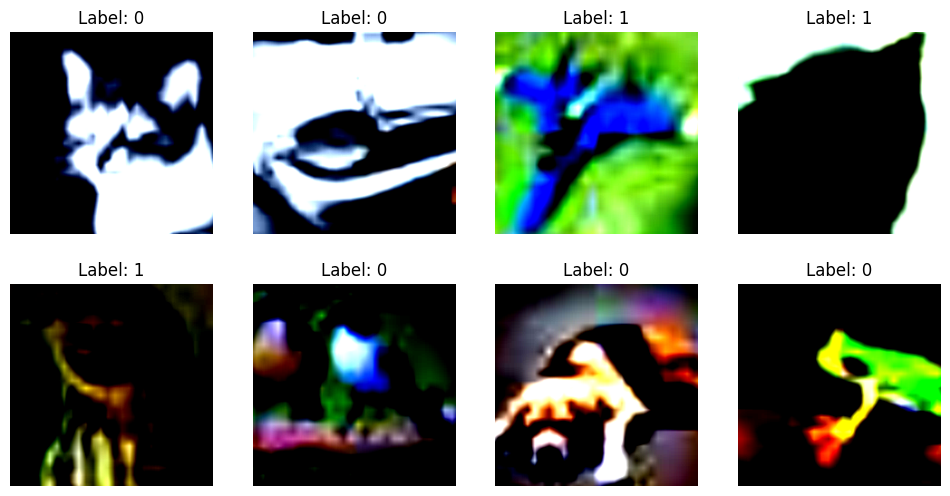

In [14]:
# get a batch of images and labels from the train loader
data_iter = iter(train_loader)
images, labels = next(data_iter)

# get the first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(8):  # show first 8 images
    ax = axes[i // 4, i % 4]
    img = images[i]  # Get image from batch
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))  # convert tensor to image
    ax.axis('off')  # Hide axis
    ax.set_title(f"Label: {labels[i].item()}")  # show the image lable

plt.show()


#### Validation Data

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.465708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.4831376].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.3410363].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2989979..2.3262744].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0182073..2.288515

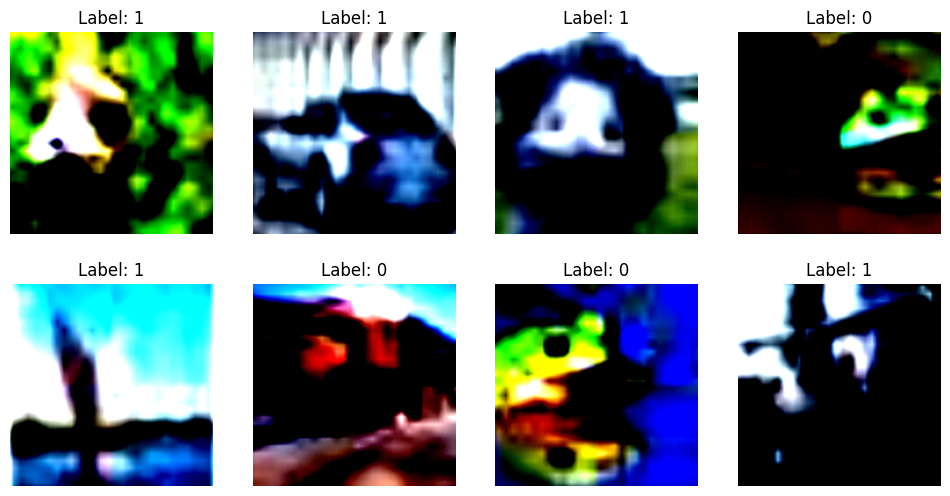

In [15]:
data_iter = iter(val_loader)
images, labels = next(data_iter)

# get the first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(8):  # show first 8 images
    ax = axes[i // 4, i % 4]
    img = images[i]  # Get image from batch
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))  # convert tensor to image
    ax.axis('off')  # Hide axis
    ax.set_title(f"Label: {labels[i].item()}")  # show the image lable

plt.show()

#### Testing Data

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.535425].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.2914162].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.3785625].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0007002..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.5179958].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..

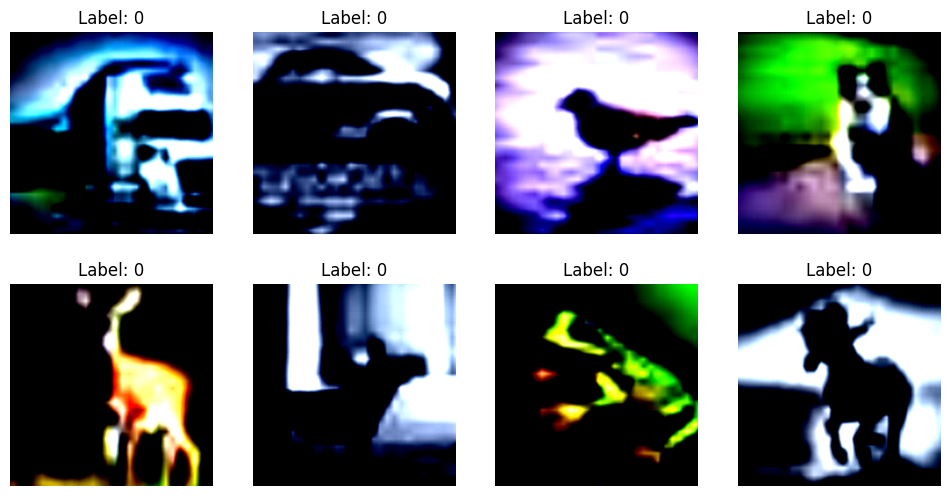

In [16]:
data_iter = iter(test_loader)
images, labels = next(data_iter)

# get the first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(8):  # show first 8 images
    ax = axes[i // 4, i % 4]
    img = images[i]  # Get image from batch
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))  # convert tensor to image
    ax.axis('off')  # Hide axis
    ax.set_title(f"Label: {labels[i].item()}")  # show the image lable

plt.show()